First 10 rows:
    age    workclass  fnlwgt     education  education.num marital.status  \
0   90            ?   77053       HS-grad              9        Widowed   
1   82      Private  132870       HS-grad              9        Widowed   
2   66            ?  186061  Some-college             10        Widowed   
3   54      Private  140359       7th-8th              4       Divorced   
4   41      Private  264663  Some-college             10      Separated   
5   34      Private  216864       HS-grad              9       Divorced   
6   38      Private  150601          10th              6      Separated   
7   74    State-gov   88638     Doctorate             16  Never-married   
8   68  Federal-gov  422013       HS-grad              9       Divorced   
9   41      Private   70037  Some-college             10  Never-married   

          occupation    relationship   race     sex  capital.gain  \
0                  ?   Not-in-family  White  Female             0   
1    Exec-managerial

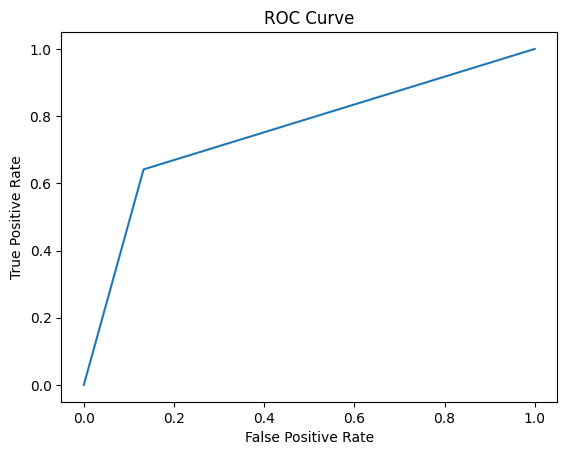


AUC: 0.7544401348865807

Cross-Validation Mean Accuracy: 0.7668602526950578
Standard Deviation: 0.01672674320834126


In [1]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)

df = pd.read_csv("adult.csv")

print("First 10 rows:\n", df.head(10))
print("\nShape:", df.shape)
print("\nFeatures:", df.columns.tolist())
df.replace('?', pd.NA, inplace=True)
df.dropna(inplace=True)


df = pd.get_dummies(df, drop_first=True)

df['income'] = df['income_>50K']


df.drop(columns=[col for col in df.columns if 'income_' in col and col != 'income'], inplace=True)
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

print("\nDecision Tree Depth:", model.get_depth())
print("Number of Leaves:", model.get_n_leaves())

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nPrecision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("\nAUC:", roc_auc)

scores = cross_val_score(model, X, y, cv=5)

print("\nCross-Validation Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Conclusion: The Adult Census dataset was successfully analyzed using a Decision Tree model. After cleaning and encoding the data,the model achieved good accuracy with balanced precision and recall. ROC and AUC showed moderate performance, while cross-validation confirmed the model’s reliability. Overall, the model can reasonably predict income levels but can be further improved for better results.